In [1]:
import pandas as pd
import seaborn as sns
from scipy import stats

# anova model from formula
from statsmodels.formula.api import ols
# anova table from ols model
from statsmodels.stats.anova import anova_lm
# for qqplot
import statsmodels.api as sm
# tukey test
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# correlation
from scipy.stats import pearsonr, spearmanr, kendalltau


1. Что оказывает наиболее сильное влияние на зарплатную вилку в вакансии?
2. Как распределены позиции (грейды) сотрудников в компаниях разного размера и какие выводы можно сделать на основе полученного распределения?
3. В какую компанию выгоднее устраиваться сотруднику, грейд которого миддл или сеньор?

In [2]:
data = pd.read_csv('data/ds_salaries.csv', index_col=0)
data.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,US,L


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           607 non-null    int64
 1   experience_level    607 non-null    str  
 2   employment_type     607 non-null    str  
 3   job_title           607 non-null    str  
 4   salary              607 non-null    int64
 5   salary_currency     607 non-null    str  
 6   salary_in_usd       607 non-null    int64
 7   employee_residence  607 non-null    str  
 8   company_location    607 non-null    str  
 9   company_size        607 non-null    str  
dtypes: int64(3), str(7)
memory usage: 47.6 KB


In [4]:
# количественные дискретные
data.work_year.unique()

array([2020, 2021, 2022])

In [5]:
# качественные
data.employment_type.unique()

<StringArray>
['FT', 'CT', 'PT', 'FL']
Length: 4, dtype: str

In [6]:
# качественные
data.job_title.unique()

<StringArray>
[                          'Data Scientist',
               'Machine Learning Scientist',
                        'Big Data Engineer',
                     'Product Data Analyst',
                'Machine Learning Engineer',
                             'Data Analyst',
                      'Lead Data Scientist',
                    'Business Data Analyst',
                       'Lead Data Engineer',
                        'Lead Data Analyst',
                            'Data Engineer',
                  'Data Science Consultant',
                          'BI Data Analyst',
                 'Director of Data Science',
                       'Research Scientist',
                 'Machine Learning Manager',
                 'Data Engineering Manager',
 'Machine Learning Infrastructure Engineer',
                              'ML Engineer',
                             'AI Scientist',
                 'Computer Vision Engineer',
                 'Principal Data Scientis

In [7]:
# качественные порядковые
data.company_size.unique(), data.experience_level.unique()

(<StringArray>
 ['L', 'S', 'M']
 Length: 3, dtype: str,
 <StringArray>
 ['MI', 'SE', 'JN', 'TL']
 Length: 4, dtype: str)

<b>1. Что оказывает наиболее сильное влияние на зарплатную вилку в вакансии?</b>

In [8]:
spearmanr(data.salary_in_usd, data.experience_level)
# статистически значимый результат и высокая корреляция

SignificanceResult(statistic=np.float64(0.5585674779878691), pvalue=np.float64(4.2973344990283406e-51))

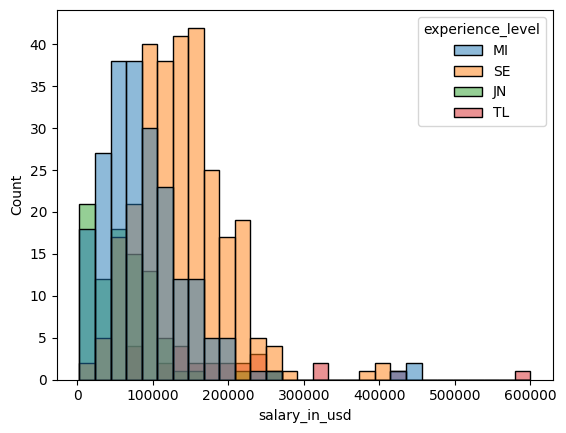

In [9]:
sns.histplot(data=data, x='salary_in_usd', hue='experience_level');

In [10]:
spearmanr(data.salary_in_usd, data.company_size)
# стат значимый результат, но низкая и отрицательная корреляция

SignificanceResult(statistic=np.float64(-0.11766706340096365), pvalue=np.float64(0.0036946213683111376))

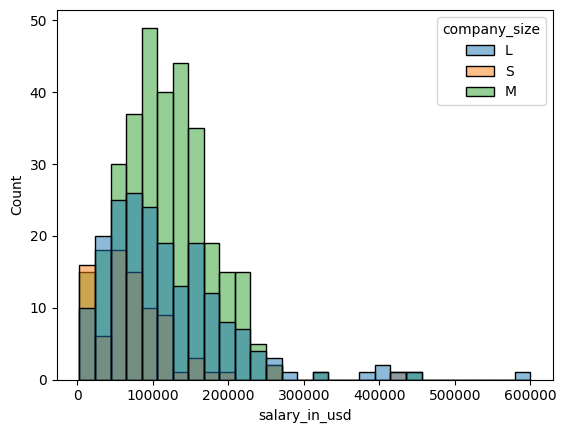

In [11]:
# распределение зарплат по размеру компании
sns.histplot(data=data, x='salary_in_usd', hue='company_size');

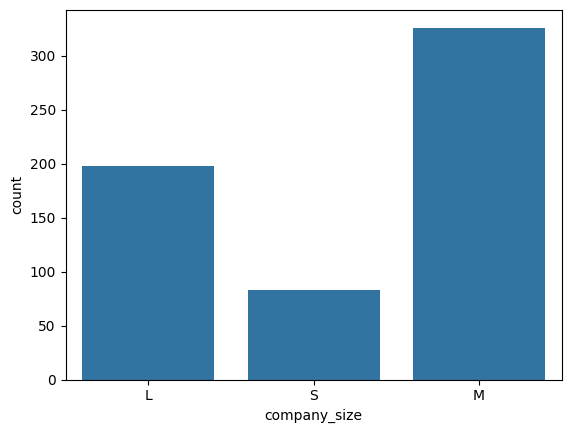

In [12]:
# количество открытых вакансий в компании в зависимости от их размера
sns.countplot(data=data, x='company_size');

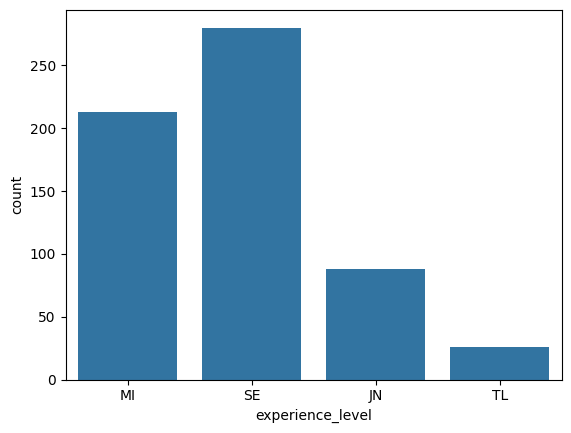

In [13]:
# количество вакансий в компании в зависимости от грейда кандидата
sns.countplot(data=data, x='experience_level');

<b>2. Как распределены позиции (грейды) сотрудников в компаниях разного размера и какие выводы можно сделать на основе полученного распределения?</b>

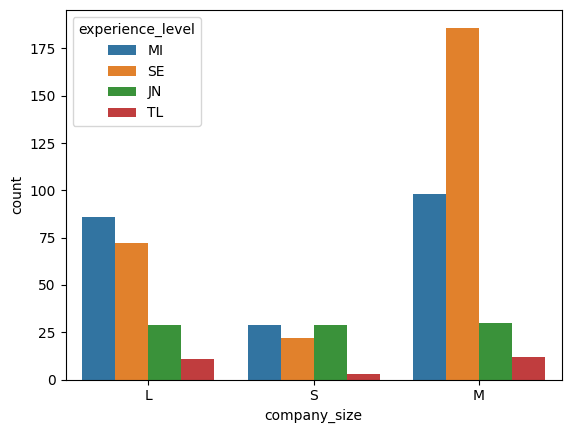

In [14]:
sns.countplot(data=data, x='company_size', hue='experience_level');

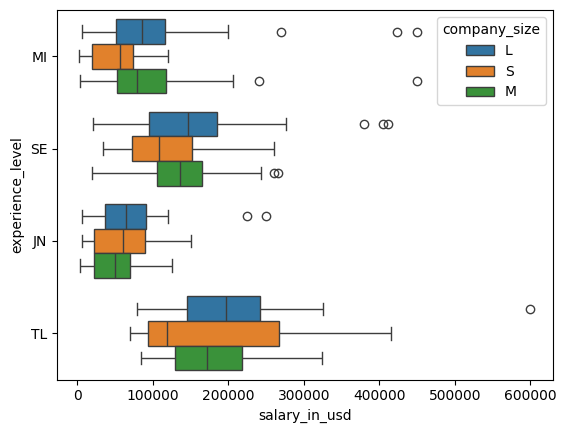

In [15]:
sns.boxplot(data=data, x='salary_in_usd', y='experience_level', hue='company_size');

<b>3. В какую компанию выгоднее устраиваться сотруднику, грейд которого миддл или сеньор?</b>

In [16]:
middle = data[data.experience_level == 'MI']

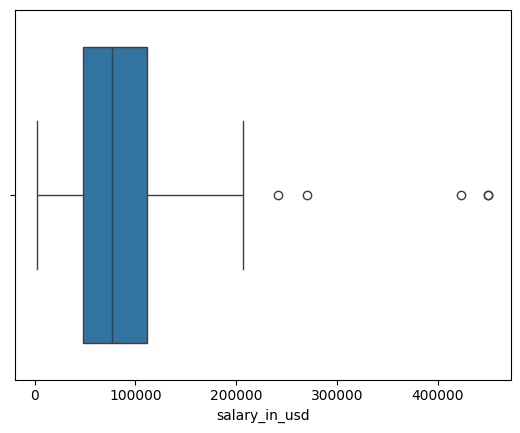

In [17]:
sns.boxplot(data=middle, x='salary_in_usd');

In [18]:
#основные статистики
middle.salary_in_usd.describe()

count       213.000000
mean      87996.056338
std       63901.057478
min        2859.000000
25%       48000.000000
50%       76940.000000
75%      112000.000000
max      450000.000000
Name: salary_in_usd, dtype: float64

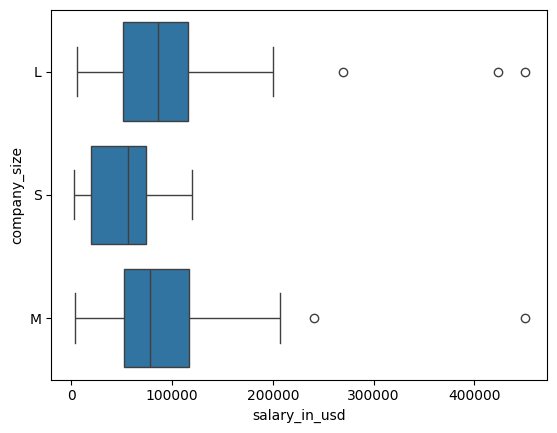

In [21]:
sns.boxplot(data=middle, x='salary_in_usd', y='company_size');

In [22]:
two_way = ols('salary_in_usd ~ company_size', middle).fit()
anova_lm(two_way)

,df,sum_sq,mean_sq,F,PR(>F)
company_size,2.0,4.844054e+10,2.422027e+10,6.223787,0.002367
Residual,210.0,8.172286e+11,3.891565e+09,NaN,NaN


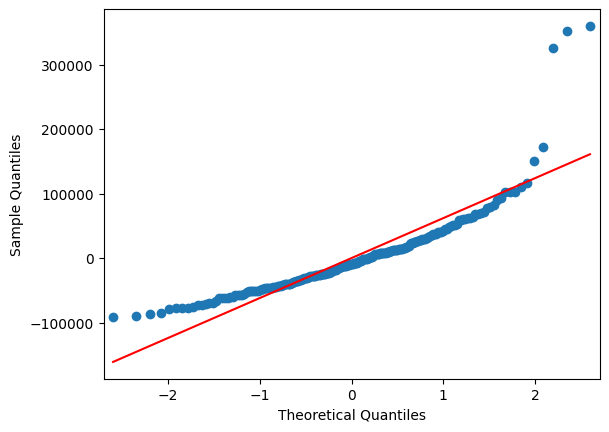

In [23]:
# проверка остатков на нормальность
sm.qqplot(two_way.resid, line='s');

In [24]:
stats.shapiro(two_way.resid)
# проверка на нормальность, остатки распределены нормально, результаты анова надежны

ShapiroResult(statistic=np.float64(0.8005948679523337), pvalue=np.float64(8.755024221237204e-16))

In [25]:
groups = []
for i, gr in data.groupby(['company_size']):
    groups.append(gr.salary_in_usd)

In [26]:
# тест Левена на равенство дисперсий
stats.levene(*groups)

LeveneResult(statistic=np.float64(6.50853451444031), pvalue=np.float64(0.0015973775552198533))

In [27]:
print(pairwise_tukeyhsd(endog=data.salary_in_usd, alpha=0.05, groups=data['company_size'])) #попарные сравнения

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj     lower       upper    reject
---------------------------------------------------------------
     L      M  -2337.5287 0.9265 -17094.0049  12418.9475  False
     L      S -41610.3203    0.0 -63026.3979 -20194.2426   True
     M      S -39272.7916    0.0 -59408.7461  -19136.837   True
---------------------------------------------------------------


In [28]:
senior = data[data.experience_level == 'SE']

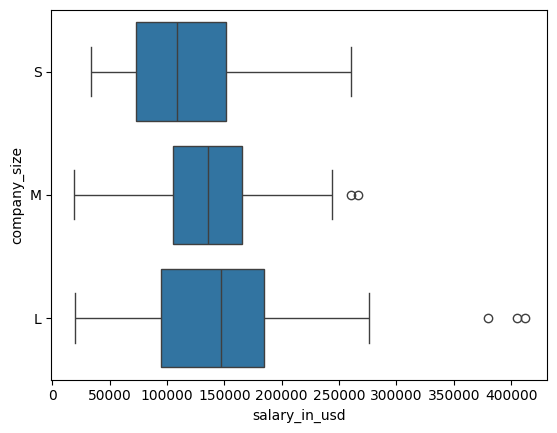

In [29]:
sns.boxplot(data=senior, x='salary_in_usd', y='company_size');

In [86]:
two_way = ols('salary_in_usd ~ company_size', senior).fit()
anova_lm(two_way)

,df,sum_sq,mean_sq,F,PR(>F)
company_size,2.0,9.408313e+09,4.704156e+09,1.807669,0.165987
Residual,274.0,7.130390e+11,2.602332e+09,NaN,NaN
